### Question 1
Create a Python function sigmoid(x) that takes a numeric input and returns the sigmoid value using the formula 1 / (1 + exp(-x)). Test your function with x = -2, 0, and 3.

The sigmoid function $\sigma(x) = \frac{1}{1 + e^{-x}}$ maps any real-valued number into the bounded probability range $(0, 1)$. Large negative inputs yield values near $0$, $x = 0$ yields exactly $0.5$, and positive inputs asymptotically approach $1$.

In [1]:
import numpy as np

# 1. Define the sigmoid function
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

# 2. Test with specified inputs: -2, 0, and 3
test_values = [-2, 0, 3]
print("Sigmoid Function Evaluation:")
for val in test_values:
    result = sigmoid(val)
    print(f"  sigmoid({val:2d}) = {result:.4f}")

Sigmoid Function Evaluation:
  sigmoid(-2) = 0.1192
  sigmoid( 0) = 0.5000
  sigmoid( 3) = 0.9526


### Question 2
Given a dataset of 10 Instagram posts with features 'likes' and 'has_caption' (1 if caption present, 0 if not), and a label 'viral' (1 if post went viral, 0 otherwise), write code to fit a logistic regression model to predict 'viral' using scikit-learn. Print the model coefficients.

A `LogisticRegression` model estimates the log-odds of a post going viral as a linear combination of its predictors: $\log\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1 (\text{likes}) + \beta_2 (\text{has\_caption})$. The positive coefficients indicate how each feature increases the likelihood of virality.

In [2]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

# Dataset of 10 Instagram posts
data = {
    'likes': [120, 450, 1500, 230, 890, 3100, 400, 5200, 610, 4200],
    'has_caption': [0, 1, 1, 0, 1, 1, 0, 1, 1, 1],
    'viral': [0, 0, 1, 0, 0, 1, 0, 1, 0, 1]
}

df_posts = pd.DataFrame(data)
X = df_posts[['likes', 'has_caption']]
y = df_posts['viral']

# Fit Logistic Regression model
clf = LogisticRegression(random_state=42)
clf.fit(X, y)

print("Model Intercept:", round(clf.intercept_[0], 4))
print("Model Coefficients:")
for feat, coef in zip(X.columns, clf.coef_[0]):
    print(f"  {feat:15s}: {coef:.6f}")

print("\nInstagram Posts Dataset:")
display(df_posts)

Model Intercept: -38.6411
Model Coefficients:
  likes          : 0.032331
  has_caption    : 0.000129

Instagram Posts Dataset:


,likes,has_caption,viral
0,120,0,0
1,450,1,0
2,1500,1,1
3,230,0,0
4,890,1,0
5,3100,1,1
6,400,0,0
7,5200,1,1
8,610,1,0
9,4200,1,1


### Question 3
Plot the sigmoid function for x values from -10 to 10 using matplotlib, and visually indicate the threshold at 0.5 on the plot.

*(Hint: Use plt.axhline() to draw the threshold line.)*

The S-shaped curve illustrates probability saturation across input log-odds. The horizontal dashed red line at $y = 0.5$ marks the standard decision threshold corresponding to the inflection point at $x = 0$.

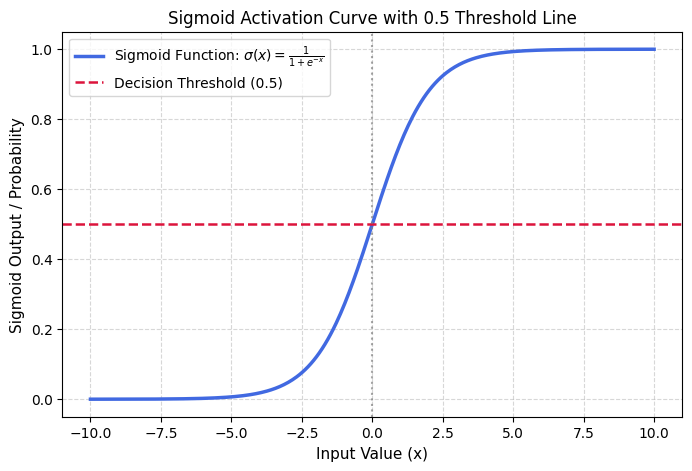

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Generate values from -10 to 10
x_vals = np.linspace(-10, 10, 400)
y_vals = sigmoid(x_vals)

plt.figure(figsize=(8, 5))
# Added 'r' before the string to make it a raw string
plt.plot(x_vals, y_vals, color='royalblue', linewidth=2.5, label=r'Sigmoid Function: $\sigma(x) = \frac{1}{1 + e^{-x}}$')
plt.axhline(y=0.5, color='crimson', linestyle='--', linewidth=1.8, label='Decision Threshold (0.5)')
plt.axvline(x=0.0, color='gray', linestyle=':', alpha=0.7)

plt.title('Sigmoid Activation Curve with 0.5 Threshold Line', fontsize=12)
plt.xlabel('Input Value (x)', fontsize=11)
plt.ylabel('Sigmoid Output / Probability', fontsize=11)
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')
plt.show()

### Question 4
Given a probability output from your logistic regression model, write a function that classifies the result as 'Viral' or 'Not Viral' based on a threshold value that you can set (default 0.5). Test your function with probabilities 0.2, 0.6, and 0.8 and thresholds 0.5 and 0.7.

Classification decision logic compares the predicted probability $\hat{p} = P(Y=1|X)$ against an adjustable threshold $\tau$: if $\hat{p} \ge \tau$, the instance is classified as **Viral**, otherwise **Not Viral**. Increasing the decision threshold from $0.5$ to $0.7$ creates a more conservative classifier requiring stronger confidence to predict virality, which shifts the classification of $0.6$ from 'Viral' to 'Not Viral'.

In [4]:
# 1. Define classification function with adjustable threshold
def classify_virality(probability, threshold=0.5):
    return 'Viral' if probability >= threshold else 'Not Viral'

# 2. Test values and thresholds
test_probabilities = [0.2, 0.6, 0.8]
test_thresholds = [0.5, 0.7]

print("Virality Classification Results:")
print("-" * 45)
for thresh in test_thresholds:
    print(f"\nEvaluating with Threshold = {thresh}:")
    for prob in test_probabilities:
        prediction = classify_virality(prob, threshold=thresh)
        print(f"  Probability: {prob:.1f}  ->  Classification: {prediction}")

Virality Classification Results:
---------------------------------------------

Evaluating with Threshold = 0.5:
  Probability: 0.2  ->  Classification: Not Viral
  Probability: 0.6  ->  Classification: Viral
  Probability: 0.8  ->  Classification: Viral

Evaluating with Threshold = 0.7:
  Probability: 0.2  ->  Classification: Not Viral
  Probability: 0.6  ->  Classification: Not Viral
  Probability: 0.8  ->  Classification: Viral
